In [236]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

In [237]:
plt.rcParams['font.sans-serif'] = 'Roboto'
plt.rcParams['font.size'] = 20
plt.rcParams['font.style'] = 'normal'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["lines.linewidth"] = 3.0

In [238]:
# importing data
df = pd.read_csv("../datasets/sales_data_cln.csv").copy()

In [239]:
color_therme = ["#3F0905", "#FA1B16", "#610B07", "#4A430F", "#7B6719", 
    "#A18A21", "#010000", "#FEFD3C", "#E6E436", "#F7F63A"]

col_ann = "#908F8F"

In [240]:
# checking columns
df.columns

Index(['user_id', 'order_id', 'purchase_ts', 'ship_ts', 'refund_ts',
       'product_name', 'product_id', 'usd_price', 'purchase_platform',
       'marketing_channel', 'account_creation_method', 'country_code',
       'purchase_y', 'purchase_ym', 'purchase_ymd', 'purchase_ymw',
       'purchase_q', 'ship_y', 'ship_ym', 'ship_ymd', 'ship_ymw', 'ship_q'],
      dtype='object')

In [241]:
# there is no explicit indication of competed order status
# however there is a refund timestamp
# hence, we assume that all NaN entries in refund are completed orders
co = df[df["refund_ts"].isna()]

# generate revenue data grouped per monht
rev_data_ym = co.groupby("purchase_ym").agg(total_revenue=("usd_price", "sum"), total_orders = ("order_id", "count")).reset_index()

# set back to datetime for plt visualization purposes
rev_data_ym["purchase_ym"] = pd.to_datetime(rev_data_ym["purchase_ym"], format="%Y-%m")

In [242]:
co["user_id"].nunique()

16862

In [243]:
# generate aggregate: average order value, rounded to the nearest hundreths place
rev_data_ym["ym_aov"] = (rev_data_ym["total_revenue"] / rev_data_ym["total_orders"]).round(2)

# up to 3rd lowest and largest in terms of revenue
low_rev = rev_data_ym.nsmallest(3, columns='total_revenue')
high_rev = rev_data_ym.nlargest(3, columns='total_revenue')

top_idx = high_rev.loc[high_rev["total_revenue"].idxmax()]
top2_idx = high_rev.loc[high_rev["total_revenue"].nlargest(2).idxmin()]
top3_idx = high_rev.loc[high_rev["total_revenue"].nlargest(3).idxmin()]

low_idx = low_rev.loc[low_rev["total_revenue"].nsmallest(1).idxmax()]
low2_idx = low_rev.loc[low_rev["total_revenue"].nsmallest(2).idxmax()]
low3_idx = low_rev.loc[low_rev["total_revenue"].nsmallest(3).idxmax()]


In [244]:
low_rev

,purchase_ym,total_revenue,total_orders,ym_aov
1,2019-02-01,72440.62,298,243.09
0,2019-01-01,91802.39,435,211.04
12,2020-01-01,94007.94,319,294.70


In [245]:
rev_data_ym["total_revenue"].mean()

np.float64(190766.00230769234)

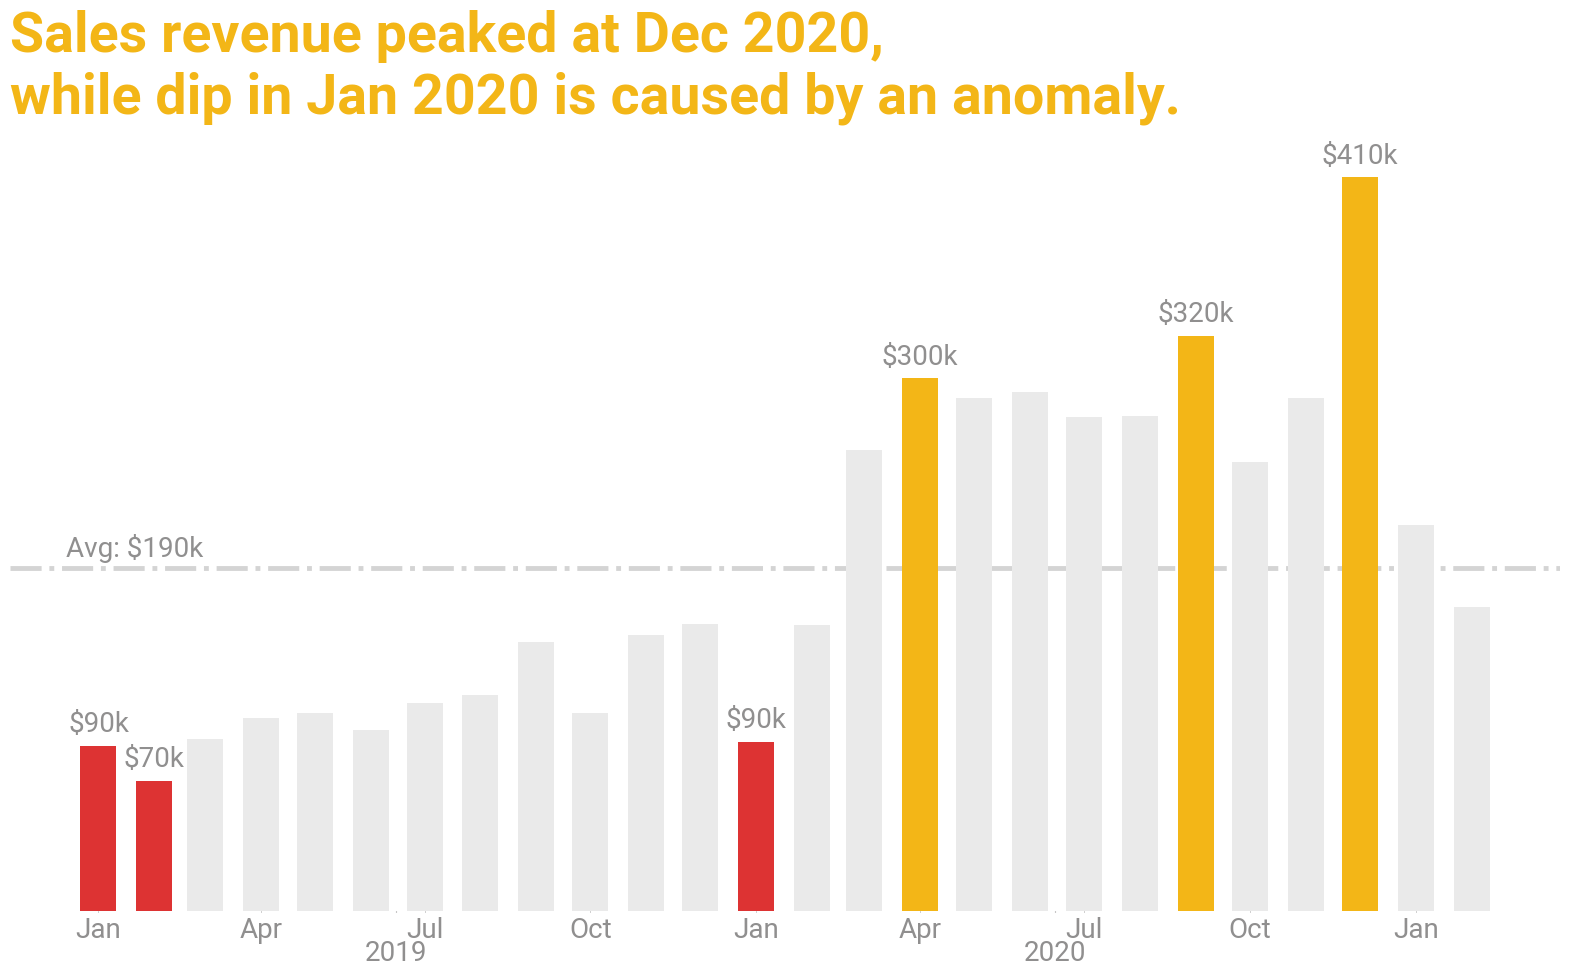

In [248]:
# here we plot the generated revenue of completed orders per month
fig, ax = plt.subplots(figsize=(20, 10))

# line avg of total generated revenue
ax.axhline(y=rev_data_ym["total_revenue"].mean(), color="#D4D4D4",
    linestyle='-.', linewidth=3.5, zorder=0)

# overall bar
ax.bar(rev_data_ym["purchase_ym"], rev_data_ym["total_revenue"],
    width = 20, color = "#EAEAEA")

# lowest and highest generated revenue
ax.bar(low_rev["purchase_ym"], low_rev["total_revenue"],
    width = 20, color = "#dd3333")
ax.bar(high_rev["purchase_ym"], high_rev["total_revenue"],
    width = 20, color = "#f3b617")


# visualizations restrictions
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.axes.get_yaxis().set_visible(False)
ax.axes.yaxis.set_ticklabels([])


# convert YYYY-MM-DD to mon and year, separately
# months (minor ticks)
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

# years (major ticks), placed mid-year so they don't collide with jan/jul
ax.xaxis.set_major_locator(mdates.YearLocator(month=6, day=15))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.tick_params(axis="x", which="major", pad=20, length=1, colors = "#908F8F") # params for years
ax.tick_params(axis="x", which="minor", pad=3, length=1, colors = "#908F8F") # params for months


# ------------------------------------------------------
# ----------- title, texts, and annotations ------------
# ------------------------------------------------------
# title
ax.set_title("Sales revenue peaked at Dec 2020, \nwhile dip in Jan 2020 is caused by an anomaly.",
    fontsize= 40, fontweight= "bold", loc= "left", color= "#f3b617", pad=20)

# Subtitle
# ax.text(0, 1.02, "Driven by asdlkjaskdg", transform=ax.transAxes,
#    fontsize=12, color = "#409d86", alpha=1)


ax.annotate(f"${int(round(top_idx["total_revenue"]/1000, -1))}k",
    xy=(top_idx["purchase_ym"], top_idx["total_revenue"]), xytext=(0, 10),
    textcoords="offset points", ha="center", fontsize = 20, zorder=10, color = "#908F8F")

ax.annotate(f"${int(round(top2_idx["total_revenue"]/1000, -1))}k",
    xy=(top2_idx["purchase_ym"], top2_idx["total_revenue"]), xytext=(0, 10),
    textcoords="offset points", ha="center", fontsize = 20, zorder=10, color = "#908F8F")

ax.annotate(f"${int(round(top3_idx["total_revenue"]/1000, -1))}k",
    xy=(top3_idx["purchase_ym"], top3_idx["total_revenue"]), xytext=(0, 10),
    textcoords="offset points", ha="center", fontsize = 20, zorder=10, color = "#908F8F")

ax.annotate(f"${int(round(low_idx["total_revenue"]/1000, -1))}k",
    xy=(low_idx["purchase_ym"], low_idx["total_revenue"]), xytext=(0, 10),
    textcoords="offset points", ha="center", fontsize = 20, zorder=10, color = "#908F8F")

ax.annotate(f"${int(round(low2_idx["total_revenue"]/1000, -1))}k",
    xy=(low2_idx["purchase_ym"], low2_idx["total_revenue"]), xytext=(0, 10),
    textcoords="offset points", ha="center", fontsize = 20, zorder=10, color = "#908F8F")

ax.annotate(f"${int(round(low3_idx["total_revenue"]/1000, -1))}k",
    xy=(low3_idx["purchase_ym"], low3_idx["total_revenue"]), xytext=(0, 10),
    textcoords="offset points", ha="center", fontsize = 20, zorder=10, color = "#908F8F")

ax.annotate(f"Avg: ${int(round(rev_data_ym["total_revenue"].mean()/1000,-1))}k", xy=(0, rev_data_ym["total_revenue"].mean()),
    xycoords=("axes fraction", "data"),  # x: 0-1 across the axes, y: data value
    xytext=(40, 4),                       # 5 pts right, 4 pts above the line
    textcoords="offset points", ha="left", va="bottom",
    fontsize=20,
    color = "#908F8F")

plt.savefig("../figures/executive_summary/executive_summary.png", transparent=True, dpi=300, bbox_inches = "tight")

plt.show()

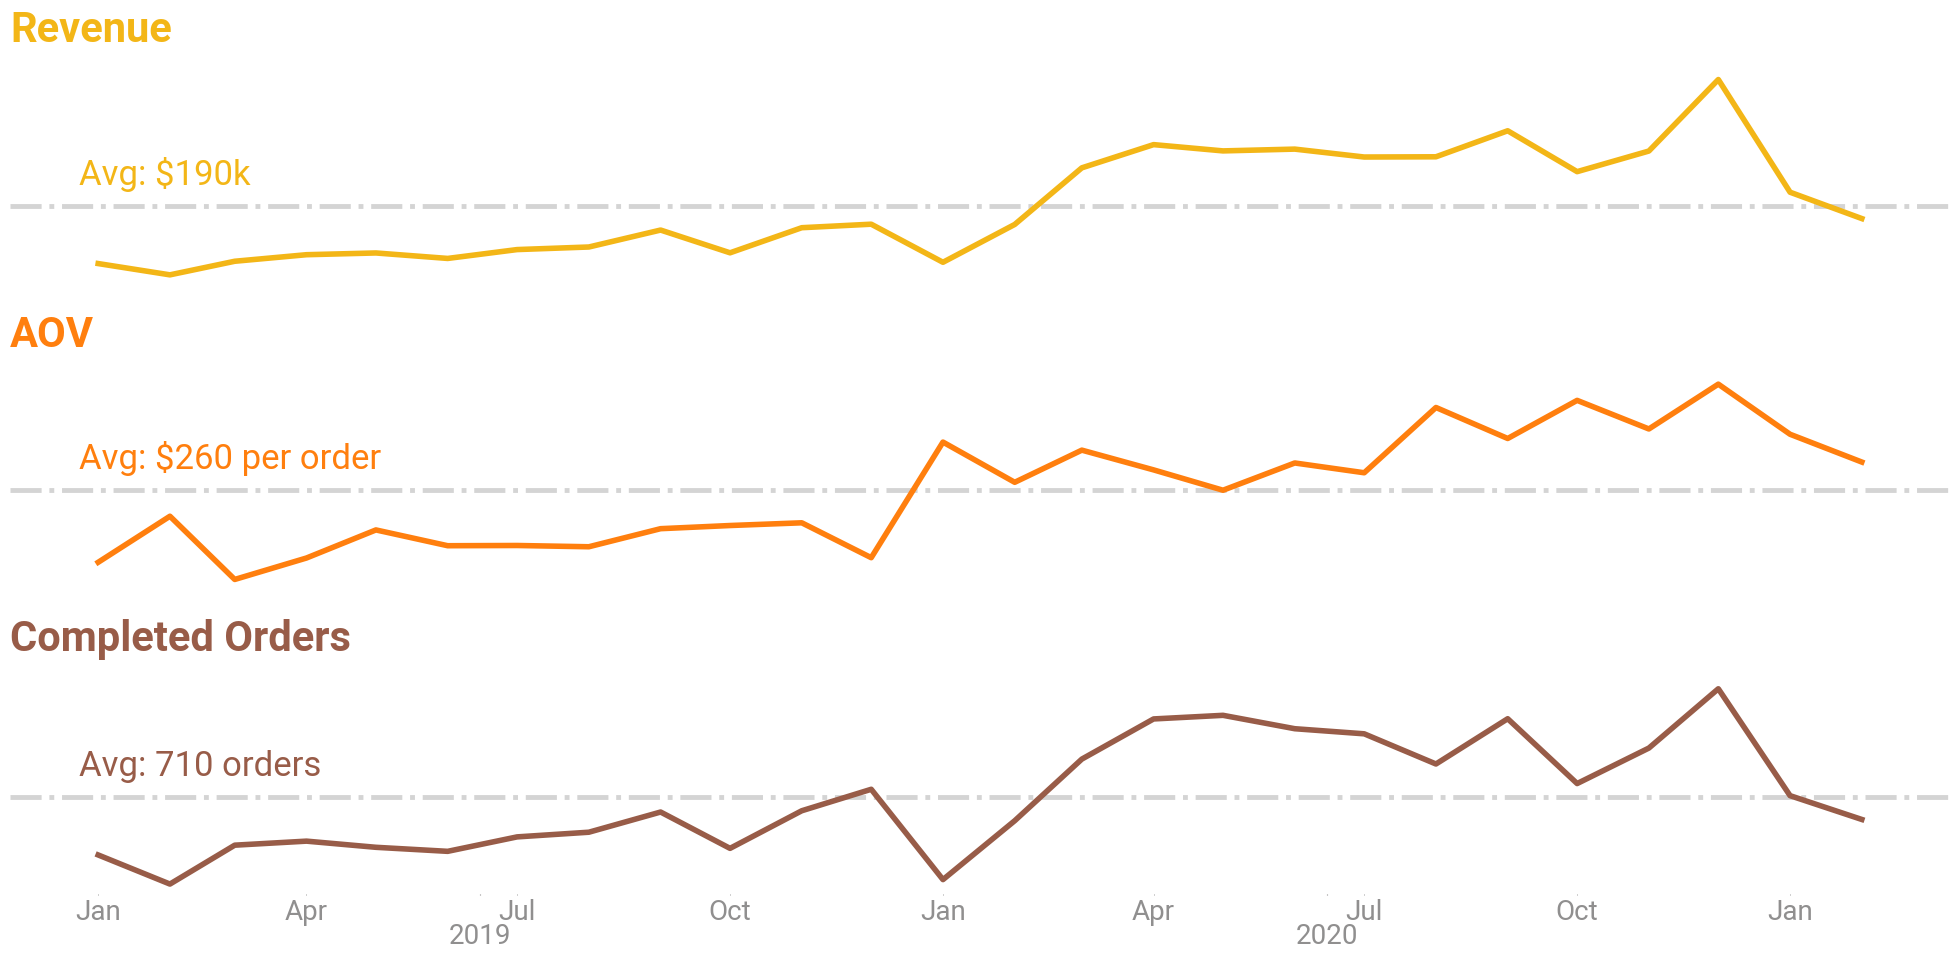

In [283]:
# Create 3 stacked subplots sharing the x-axis
fig, ax = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(20, 10))

# Plot data on each axis
# ax[0].axhline(y=rev_data_ym["total_revenue"].mean(), color='red', linestyle='--', linewidth=1)
ax[0].plot(rev_data_ym["purchase_ym"], rev_data_ym["total_revenue"],
    color= "#f3b617", linewidth=4)
ax[0].axhline(y=rev_data_ym["total_revenue"].mean(), color="#D4D4D4",
    linestyle='-.', linewidth=3.5, zorder=0)

ax[0].set_title(
    "Revenue",
    fontsize=30,
    fontweight="bold",
    loc="left",
    color = "#f3b617",
    pad=20
)

ax[0].annotate(f"Avg: ${int(round(rev_data_ym["total_revenue"].mean()/1000, -1))}k", xy=(0, rev_data_ym["total_revenue"].mean()),
    xycoords=("axes fraction", "data"),  # x: 0-1 across the axes, y: data value
    xytext=(50, 10),                       # 5 pts right, 4 pts above the line
    textcoords="offset points", ha="left", va="bottom",
    fontsize=25, color = "#f3b617")

ax[0].set_ylabel('total_revenue')
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].spines["left"].set_visible(False)
ax[0].spines["bottom"].set_visible(False)
ax[0].axes.get_xaxis().set_visible(False)
ax[0].axes.get_yaxis().set_visible(False)



# ax[1].axhline(y=rev_data_ym["ym_aov"].mean(), color='red', linestyle='--', linewidth=1)
ax[1].plot(rev_data_ym["purchase_ym"], rev_data_ym["ym_aov"], color='tab:orange', linewidth=4)
ax[1].axhline(y=rev_data_ym["ym_aov"].mean(), color="#D4D4D4",
    linestyle='-.', linewidth=3.5, zorder=0)


ax[1].set_ylabel('aov')
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)
ax[1].spines["left"].set_visible(False)
ax[1].spines["bottom"].set_visible(False)
ax[1].axes.get_xaxis().set_visible(False)
ax[1].axes.get_yaxis().set_visible(False)

ax[1].set_title("AOV",
    fontsize=30, fontweight="bold",
    loc="left", color = "tab:orange", pad=20)

ax[1].annotate(f"Avg: ${int(round(rev_data_ym["ym_aov"].mean(), -1))} per order", xy=(0, rev_data_ym["ym_aov"].mean()),
    xycoords=("axes fraction", "data"),  # x: 0-1 across the axes, y: data value
    xytext=(50, 10),                       # 5 pts right, 4 pts above the line
    textcoords="offset points", ha="left", va="bottom",
    fontsize=25, color = "tab:orange")


ax[2].plot(rev_data_ym["purchase_ym"], rev_data_ym["total_orders"], color="#985c48", linewidth=4)
ax[2].axhline(y=rev_data_ym["total_orders"].mean(), color="#D4D4D4",
    linestyle='-.', linewidth=3.5, zorder=0)

ax[2].set_ylabel('total_orders')
ax[2].spines["top"].set_visible(False)
ax[2].spines["right"].set_visible(False)
ax[2].spines["left"].set_visible(False)
ax[2].spines["bottom"].set_visible(False)
# ax[2].axes.get_xaxis().set_visible(False)
ax[2].axes.get_yaxis().set_visible(False)

ax[2].set_title(
    "Completed Orders",
    fontsize=30,
    fontweight="bold",
    loc="left",
    color = "#985c48",
    pad=20
)


ax[2].annotate(f"Avg: {int(round(rev_data_ym["total_orders"].mean(), -1))} orders", xy=(0, rev_data_ym["total_orders"].mean()),
    xycoords=("axes fraction", "data"),  # x: 0-1 across the axes, y: data value
    xytext=(50, 10),                       # 5 pts right, 4 pts above the line
    textcoords="offset points", ha="left", va="bottom",
    fontsize=25,
    color = "#985c48")

# Set the x-label on the bottom plot only
# ax[2].set_xlabel('X Axis')


#####
ax[2].xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax[2].xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

# years (major ticks), placed mid-year so they don't collide with Jan/Jul
ax[2].xaxis.set_major_locator(mdates.YearLocator(month=6, day=15))
ax[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

#params for years
ax[2].tick_params(axis="x", which="major", pad=20, length=1, 
    colors= "#908F8F")
# params for months
ax[2].tick_params(axis="x", which="minor", pad=3, length=1,
    colors= "#908F8F") 



fig.subplots_adjust(hspace=0)
# Adjust layout to prevent clipping
plt.tight_layout()

plt.savefig("../figures/sales/sales.png", transparent=True, dpi=300)
plt.show()

In [ ]:
rev_data_ym["total_rev_growth_pct"] = (100.0 * (rev_data_ym["total_revenue"] - rev_data_ym["total_revenue"].shift(1))/rev_data_ym["total_revenue"]).round(1)
rev_data_ym["total_orders_growth_pct"] = (100.0 * (rev_data_ym["total_orders"] - rev_data_ym["total_orders"].shift(1))/rev_data_ym["total_orders"]).round(1)
rev_data_ym["ym_aov_growth_pct"] = (100.0 * (rev_data_ym["ym_aov"] - rev_data_ym["ym_aov"].shift(1))/rev_data_ym["ym_aov"]).round(1)
rev_data_ym

,purchase_ym,total_revenue,total_orders,ym_aov,total_rev_growth_pct,total_orders_growth_pct,ym_aov_growth_pct
0,2019-01-01,91802.39,435,211.04,NaN,NaN,NaN
1,2019-02-01,72440.62,298,243.09,-26.7,-46.0,13.2
2,2019-03-01,95762.11,481,199.09,24.4,38.0,-22.1
3,2019-04-01,107012.02,500,214.02,10.5,3.8,7.0
4,2019-05-01,110005.20,471,233.56,2.7,-6.2,8.4
5,2019-06-01,100603.50,452,222.57,-9.3,-4.2,-4.9
6,2019-07-01,115821.61,520,222.73,13.1,13.1,0.1
7,2019-08-01,120240.82,542,221.85,3.7,4.1,-0.4
8,2019-09-01,149331.91,637,234.43,19.5,14.9,5.4
9,2019-10-01,110267.37,466,236.63,-35.4,-36.7,0.9


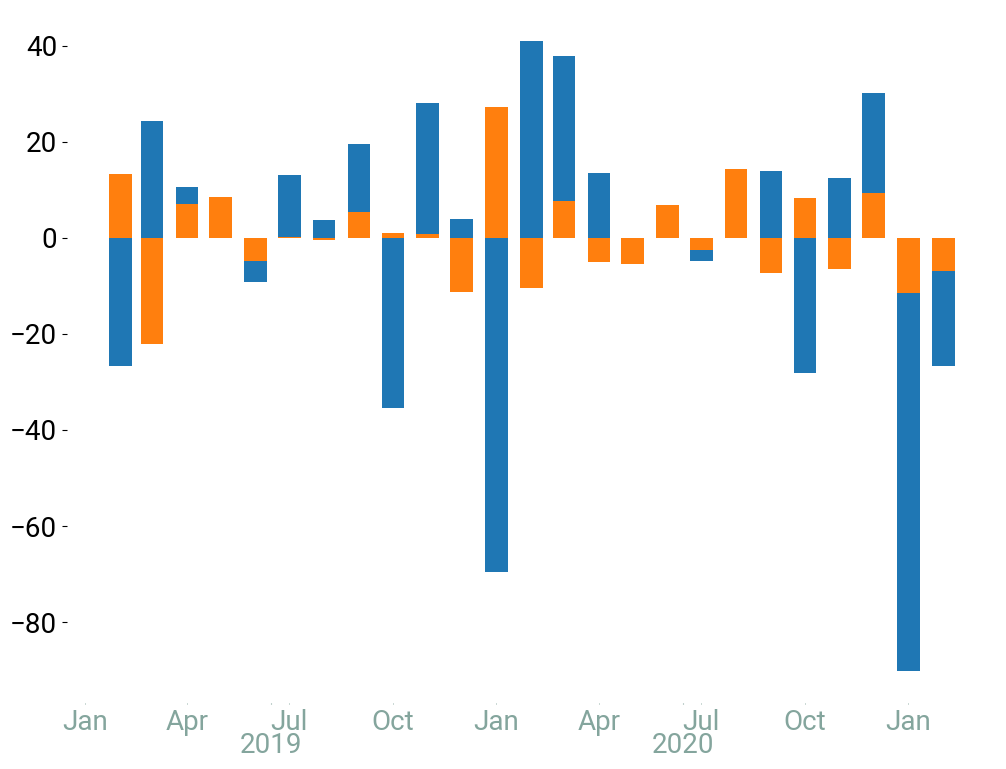

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))

# ax.bar(rev_data_ym["order_year_month"], rev_data_ym["total_net_revenue"], label='Product A', color='#4dabf7')

# ax.bar(rev_data_ym["purchase_ym"], rev_data_ym["total_orders_growth_pct"], width=20)
ax.bar(rev_data_ym["purchase_ym"], rev_data_ym["total_rev_growth_pct"], width=20)
ax.bar(rev_data_ym["purchase_ym"], rev_data_ym["ym_aov_growth_pct"], width=20)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
# ax.axes.get_xaxis().set_visible(False)
# ax.axes.get_yaxis().set_visible(False)
# ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
# ax.axes.xaxis.set_ticklabels([])
# ax.axes.yaxis.set_ticklabels([])

ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

# years (major ticks), placed mid-year so they don't collide with Jan/Jul
ax.xaxis.set_major_locator(mdates.YearLocator(month=6, day=15))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.tick_params(axis="x", which="major", pad=20, length=1, colors= "#84a59d") # params for years
ax.tick_params(axis="x", which="minor", pad=3, length=1, colors= "#84a59d") # params for months



plt.savefig("../figures/sales/sales_vs_aov.png", transparent=True, dpi=300)

plt.show()